# Suzuki Trotter 和 Taylor_Series 解决 Hamiltonian Simulation 问题
----

## Hamiltonian Simulation

### 1. Hamiltonian Simulation 在做什么
量子系统满足 Schrödinger方程，即
$$
i\frac{d}{dt}\ket{\psi(t)} = H\ket{\psi(t)}
$$
若 H 不随时间变化, 则可以得到
$$
\ket{\psi(t)} = e^{-iHt}\ket{\psi(0)}
$$
因此 Hamiltonian Simulation 的任务就是
$$
H\to U(t)=e^{-iHt}
$$

### 2. 本节统一实验 Hamiltonian
本节使用一个简单但不对易的 qubit Hamiltonian:
$$
H=X+0.7Z=\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix} + 0.7\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}=\begin{bmatrix}
0.7&1\\
1&-0.7
\end{bmatrix}
$$
取值 $t=1$.

此例子非常合适, 因为二者不对易, 即 $[X, Z]\ne 0$, 因为若它们对易, 则有
$$
e^{-i(X+0.7Z)t}=e^{-iXt}e^{-i0.7Zt}
$$
Trotter 精确成立.

### 3. 精确演化作为 benchmark
由
$$
X^2=Z^2=I,\quad XZ+ZX=0
$$
可以得出
$$
H^2=\omega^2 I,\quad \omega=\sqrt{1.49}
$$
因此将其精确写为
$$
U_{exact}=e^{-iHt}=\cos(\omega t)I-i\frac{\sin(\omega t)}{\omega}H
$$

In [1]:
# 首先定义 Hamiltonian
import math

import numpy as np

# 定义矩阵
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = X + 0.7 * Z
t = 1.0

# 手写 e^{-iHt}
omega = math.sqrt(1 + 0.7**2)
U_exact = math.cos(omega * t) * I - 1j * math.sin(omega * t) / omega * H

# 检查是否为酉
exact_unitarity_error = np.linalg.norm(U_exact.conj().T @ U_exact - I)

print("Exact unitarity error =", exact_unitarity_error)

Exact unitarity error = 1.6442912118261195e-16


## Suzuki-Trotter

### 1. 为什么需要 Suzuki-Trotter 分段分解？
假设
$$
H = A + B
$$
真正想要的是
$$
e^{-i(A + B)t}
$$
若 $[A, B]=0$, 则有
$$
e^{-i(A + B)t} = e^{-iAt}e^{-iBt}
$$
但通常不满足, 于是有
$$
e^{-i(A+B)t} \neq e^{-iAt}e^{-iBt}
$$
Trotter 的想法是
> 不用一次演化 $t$, 而是切成很多个短的 $\Delta t$

### 2. 一阶 Lie-Trotter
令
$$
\Delta t = \frac{t}{r}
$$
一阶公式为: 
$$
e^{-i(A+B)t}\approx \left( e^{-iA\Delta t}e^{-iB\Delta t} \right)^r
$$
对于上述例子, 有
$$
U_{LT}=\left(e^{-iXt/r}e^{-i0.7Zt/r}\right)^r
$$
Unitarylab 官方的 Suzuki-Trotter 实现也是先把 Hamiltonian 分解为 Pauli 项, 再构造单时间片, 最后重复 steps 次.

利用 BCH 展开:
$$
e^{A\Delta t}e^{B\Delta t} = e^{(A+B)\Delta t+\frac{1}{2}[A, B]\Delta t^2+\cdots}
$$
所以误差核心来自 $[A, B]$ 项.

一阶 Lie-Trotter 的全局误差尺度通常写为
$$
O\left( \frac{t^2\|[A, B]\|}{r} \right)
$$

### 3. 二阶 Suzuki/Strang splitting
为了提高精度, 可以使用对称分解
$$
e^{-i(A+B)\Delta t}\approx e^{-iA\Delta t/2}e^{-iB\Delta t}e^{-iA\Delta t/2}
$$
完整演化为
$$
U_{S_2}=\left(e^{-iAt/(2r)}e^{-iBt/r}e^{-iAt/(2r)}\right)^r
$$
全局误差改善为
$$
O\left(\frac{t^3}{r^2}\right)
$$

### 4. 更高阶 Suzuki
更高阶的 $S_{2k}$, 可以通过递归构造:
$$
S_{2k}(t)=S_{2k-2}(p_k t)^2 S_{2k-2}((1-4p_k)t)S_{2k-2}(p_k t)^2
$$
其中
$$
p_k=\frac{1}{4^{1/(2k-1)}}
$$

In [2]:
# 实现 Suzuki-Trotter 分解
def pauli_evolution(P, angle):

    return np.cos(angle) * I - 1j * np.sin(angle) * P


def first_order_trotter(steps):
    dt = t / steps
    U_x = pauli_evolution(X, dt)
    U_z = pauli_evolution(Z, 0.7 * dt)
    U_slice = U_x @ U_z

    return np.linalg.matrix_power(U_slice, steps)


def second_order_trotter(steps):
    dt = t / steps
    U_x_half = pauli_evolution(X, dt / 2)
    U_z = pauli_evolution(Z, 0.7 * dt)
    U_slice = U_x_half @ U_z @ U_x_half

    return np.linalg.matrix_power(U_slice, steps)

In [3]:
# 实现一阶
steps = 12

U_trotter_1 = first_order_trotter(steps)
error_trotter_1 = np.linalg.norm(U_trotter_1 - U_exact, ord="fro")

print("First-order Trotter error =", error_trotter_1)

First-order Trotter error = 0.0635271177812162


In [4]:
# 实现二阶
U_trotter_2 = second_order_trotter(steps)
error_trotter_2 = np.linalg.norm(U_trotter_2 - U_exact, ord="fro")

print("Second-order Suzuki error =", error_trotter_2)

Second-order Suzuki error = 0.0015752064802247161


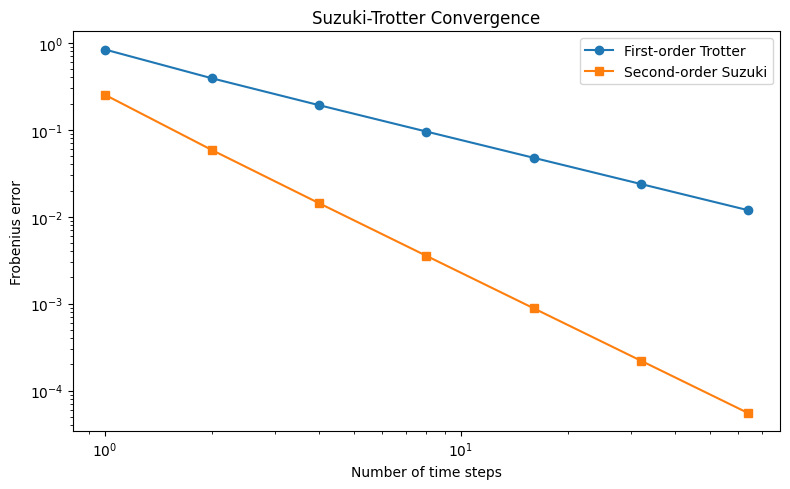

In [5]:
# 绘制步数与误差图
import matplotlib.pyplot as plt

step_values = [1, 2, 4, 8, 16, 32, 64]

first_errors = []
second_errors = []


for r in step_values:
    U_1 = first_order_trotter(r)
    U_2 = second_order_trotter(r)

    first_errors.append(np.linalg.norm(U_1 - U_exact, ord="fro"))
    second_errors.append(np.linalg.norm(U_2 - U_exact, ord="fro"))

fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(step_values, first_errors, marker="o", label="First-order Trotter")
ax.loglog(step_values, second_errors, marker="s", label="Second-order Suzuki")

ax.set_xlabel("Number of time steps")
ax.set_ylabel("Frobenius error")
ax.set_title("Suzuki-Trotter Convergence")
ax.legend()
fig.tight_layout()

plt.show()

[TROTTER_HS]: Starting Trotter Hamiltonian Simulation Algorithm
[TROTTER_HS]: Input parameters: 
        - Hamiltonian = [[ 0.7+0.j  1. +0.j]
 [ 1. +0.j -0.7+0.j]]
        - Evolution time = 1.0
        - error = 0.001
        - order of Trotter formula = 2
        - steps of Trotter formula = 12
[TROTTER_HS]: Stage 1: Formatting and validating input.
[TROTTER_HS]:     Hamiltonian dimension: 2, number of qubits: 1, spectral norm: 1.2207.
[TROTTER_HS]:     Chosen Trotter order: 2, number of simulation steps: 12.
[TROTTER_HS]: Stage 2: Decomposing Hamiltonian into Pauli terms.
[TROTTER_HS]:     Decomposed Hamiltonian into 2 Pauli terms.
[TROTTER_HS]: Stage 3: Building Trotter circuit for one time slice.
[TROTTER_HS]: Output information: 
        - Approximate evolution matrix = [[ 3.43466802e-01-0.53753259j  1.61119149e-16-0.77012289j]
 [-9.08739471e-18-0.77012289j  3.43466802e-01+0.53753259j]]
        - Exact evolution matrix = [[3.43030035e-01-0.53866719j 5.55111512e-17-0.76952456j]
 [

e:\Miniforge3\envs\py-qiskit\Lib\site-packages\unitarylab_algorithms\hamiltonian_simulation\trotter\algorithm.py:90: ComplexWarning: Casting complex values to real discards the imaginary part
  gate = pauli_string_evolution(pauli_str, angle)


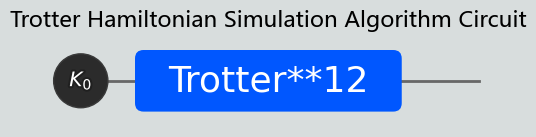

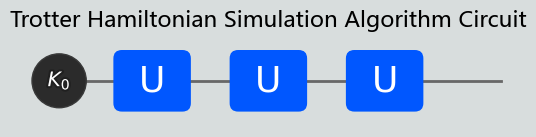

In [6]:
# 官方实现
from unitarylab_algorithms import TrotterAlgorithm

%matplotlib inline
trotter_algorithm = TrotterAlgorithm(text_mode="plain")
trotter_result = trotter_algorithm.run(
    H=H,
    t=t,
    error=1e-3,
    order=2,
    steps=12,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [7]:
# 官方数值结果
official_trotter_U = np.asarray(trotter_result["Approximate evolution matrix"])
official_exact_U = np.asarray(trotter_result["Exact evolution matrix"])
official_trotter_error = trotter_result["Frobenius norm of error"]

print("Manual second-order error =", error_trotter_2)
print("Official Trotter error =", official_trotter_error)

Manual second-order error = 0.0015752064802247161
Official Trotter error = 0.0019162924150894092


## Taylor Series

### 1. 截断 Taylor Series
Taylor展开可以知道
$$
e^x=\sum_{k=0}^{\infty}\frac{x^k}{k!}
$$
令 $x=-iHt$, 则
$$
e^{-iHt}=\sum_{k=0}^{\infty}\frac{(-iHt)^k}{k!}
$$
但我们不能保留无穷多项, 因此只保留到 K:
$$
U_k(t)=\sum_{k=0}^{K}\frac{(-iHt)^k}{k!}
$$
随着 K 的增大, Taylor展开的精度会越高, 误差会越小.

### 2. 为什么 Taylor 法也要对时间切片？
直接对 $Ht$ 做高阶 Taylor, 在 $t\|H\|$ 很大时, 需要很高阶.因此仍然可以
$$
t=r\Delta t
$$
先近似
$$
e^{-iH\Delta t}\approx \sum_{k=0}^{K}\frac{(-iH\Delta t)^k}{k!}
$$
然后
$$
e^{-iHt}\approx \left[ \sum_{k=0}^{K}\frac{(-iHt/r)^k}{k!}  \right]^r
$$

### 数值实现
后续的数值实现使用的是递推关系:
$$
T_k=T_{k-1}\times \frac{-iH\Delta t}{k}
$$

In [8]:
# 手写截断 Taylor
def truncated_taylor_slice(H, dt, degree):
    dim = H.shape[0]
    result = np.eye(dim, dtype=complex)
    term = np.eye(dim, dtype=complex)

    for k in range(1, degree + 1):
        term = term @ (-1j * H * dt) / k
        result += term

        return result


alpha = np.linalg.norm(H, 2)
r_taylor = int(alpha * t / 0.5) + 1

print("Taylor time slices =", r_taylor)

Taylor time slices = 3


In [9]:
degree = 15

dt_taylor = t / r_taylor
U_taylor_slice = truncated_taylor_slice(H, dt_taylor, degree)
if U_taylor_slice is not None:
    U_taylor = np.linalg.matrix_power(U_taylor_slice, r_taylor)
else:
    raise ValueError("Truncated Taylor slice is None")

manual_taylor_error = np.linalg.norm(U_taylor - U_exact, ord="fro")
print("Manual Taylor error =", manual_taylor_error)

Manual Taylor error = 0.3781002253335929


In [10]:
# 检查不一定是 unitary
taylor_unitarity_error = np.linalg.norm(U_taylor.conj().T @ U_taylor - I)

print("Taylor unitarity error =", taylor_unitarity_error)

Taylor unitarity error = 0.8250949659439324


## 因此可以连接到 LCU 部分

[TAYLOR_HS]: Starting Taylor Hamiltonian Simulation Algorithm
[TAYLOR_HS]: Input parameters: 
        - Hamiltonian = [[ 0.7+0.j  1. +0.j]
 [ 1. +0.j -0.7+0.j]]
        - Evolution time = 1.0
        - error = 0.001
        - degree = 15
[TAYLOR_HS]: Stage 1: Formatting and validating input.
[TAYLOR_HS]:     Formatted Hamiltonian dimension: 2 (n=1 qubits)
[TAYLOR_HS]:     Spectral norm (alpha): 1.2207
[TAYLOR_HS]:     Degree of expansion: 15
[TAYLOR_HS]: Stage 2: Decomposing Hamiltonian into Pauli strings.
[TAYLOR_HS]:     Decomposed Hamiltonian into 2 Pauli strings.
[TAYLOR_HS]: Stage 3: Building Taylor series expansion for one time slice and converting to LCU format.
[TAYLOR_HS]:     Constructed Taylor series with 4 unique Pauli string terms for one slice.
[TAYLOR_HS]: Stage 4: Raising the single-slice operator to the power r to approximate exp(-iHt) and converting to LCU format.
[TAYLOR_HS]:     Constructed LCU terms with 4 components.
[TAYLOR_HS]: Stage 5: Building the LCU circuit 

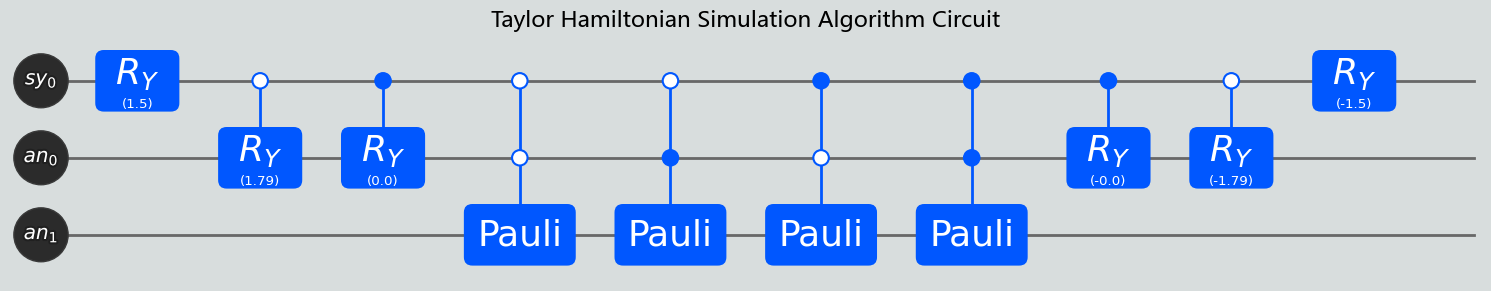

In [11]:
# 官方实现
from unitarylab_algorithms import TaylorAlgorithm

taylor_algorithm = TaylorAlgorithm(text_mode="plain")
taylor_result = taylor_algorithm.run(
    H=H,
    t=t,
    error=1e-3,
    degree=15,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [12]:
official_taylor_U = np.asarray(taylor_result["Approximate evolution matrix"])
official_taylor_exact = np.asarray(taylor_result["Exact evolution matrix"])
official_taylor_error = taylor_result["Frobenius norm of error"]

print("\n========== Taylor Comparison ==========")
print("Manual Taylor error =", manual_taylor_error)
print("Official Taylor error =", official_taylor_error)
print(
    "Manual vs Official operator error =",
    np.linalg.norm(U_taylor - official_taylor_U, ord="fro"),
)


========== Taylor Comparison ==========
Manual Taylor error = 0.3781002253335929
Official Taylor error = 1.2035184975564303e-15
Manual vs Official operator error = 0.37810022533359183


In [13]:
print("\n========== Hamiltonian Simulation ==========")
print("First-order Trotter error =", error_trotter_1)
print("Second-order Suzuki error =", error_trotter_2)
print("Taylor error =", manual_taylor_error)


========== Hamiltonian Simulation ==========
First-order Trotter error = 0.0635271177812162
Second-order Suzuki error = 0.0015752064802247161
Taylor error = 0.3781002253335929


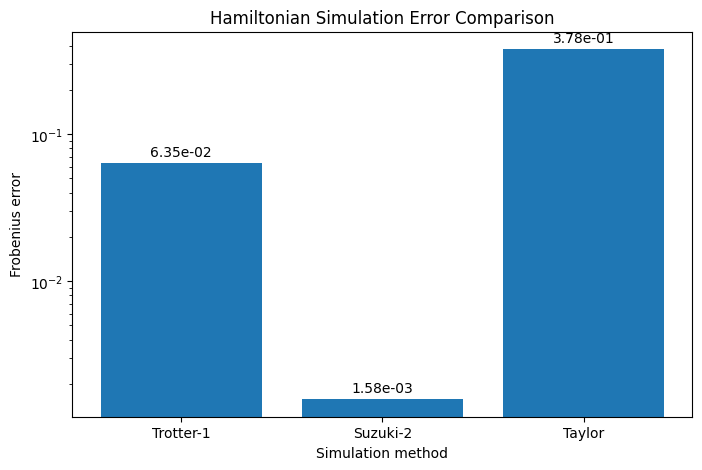

In [14]:
# 绘制误差图
%matplotlib inline
methods = ["Trotter-1", "Suzuki-2", "Taylor"]

errors = [error_trotter_1, error_trotter_2, manual_taylor_error]


fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, errors)
ax.bar_label(bars, labels=[f"{error:.2e}" for error in errors], padding=3)

ax.set_yscale("log")
ax.set_xlabel("Simulation method")
ax.set_ylabel("Frobenius error")
ax.set_title("Hamiltonian Simulation Error Comparison")
# fig.tight_layout()

plt.show()

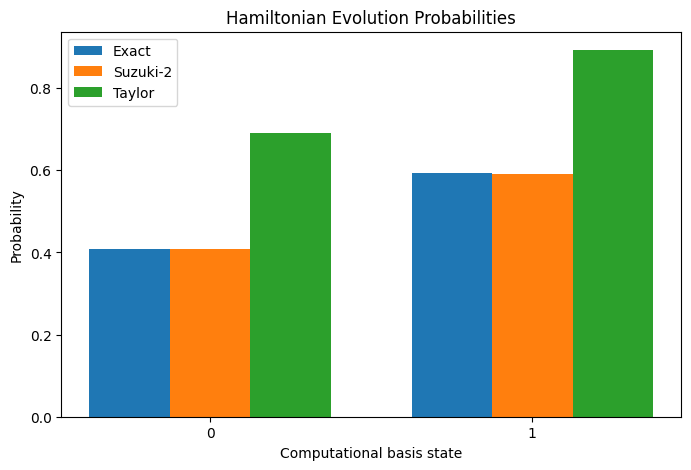

In [15]:
# 比较状态演化
psi_0 = np.array([1, 0], dtype=complex)
psi_exact = U_exact @ psi_0

psi_trotter = U_trotter_2 @ psi_0

psi_taylor = U_taylor @ psi_0

# 概率比较
exact_probabilities = np.abs(psi_exact) ** 2
trotter_probabilities = np.abs(psi_trotter) ** 2
taylor_probabilities = np.abs(psi_taylor) ** 2

# 绘制概率分布
basis_states = ["0", "1"]

x = np.arange(len(basis_states))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, exact_probabilities, width, label="Exact")
ax.bar(x, trotter_probabilities, width, label="Suzuki-2")
ax.bar(
    x + width,
    taylor_probabilities,
    width,
    label="Taylor",
)

ax.set_xticks(x)
ax.set_xticklabels(basis_states)
ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_title("Hamiltonian Evolution Probabilities")
ax.legend()
# fig.tight_layout()

plt.show()